Part 1: Data Preparation and Exploration

1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller,acf,pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.tsa.api as smt

In [23]:
df = pd.read_csv('exchange_rate.csv')

In [24]:
df.shape

(7588, 2)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [26]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [27]:
exchange = pd.read_csv('exchange_rate.csv',parse_dates=['date'],index_col='date')

In [28]:
exchange.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [29]:
import matplotlib.dates as mdates

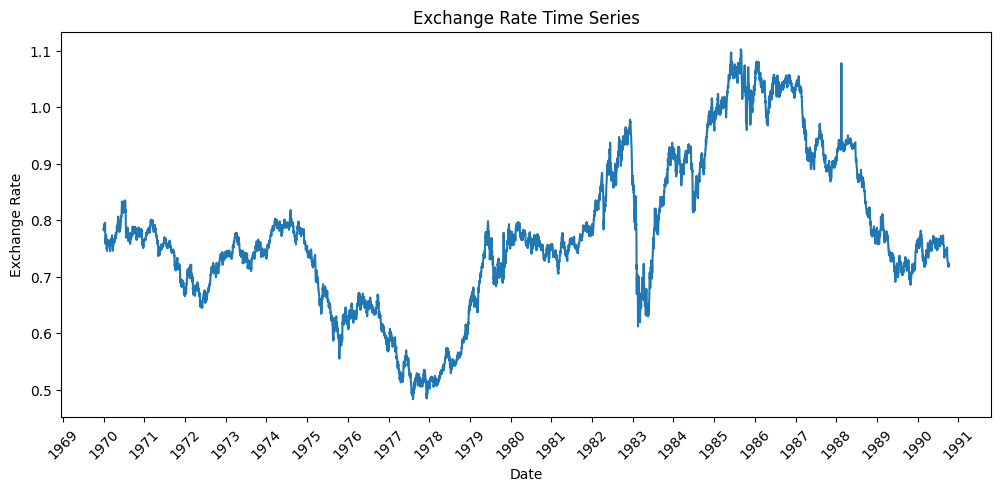

In [30]:
plt.figure(figsize=(12,5))
plt.plot(exchange['Ex_rate'])

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Exchange Rate Time Series')
plt.xticks(rotation=45)
plt.show()

From the above plot we can see
- 1970 to middle of 1972 - Clear dropping of trend
- From middle of 1972 to 1975 - Gradual rising trend
- 1975 to 1976 - Sudden drop of trend
- 1976 to 1977 - Slow rise of trend
- 1977 to 1978 - Sudden drop of trend
- 1978 to middle of 1979 - Sudden rise of trend
- From middle of 1979 to 1982 - Sudden drop then sudden rise after that there is no rise or drop of trend until 1982
- 1982 to 1983 - Sudden rise of trend
- From last of 1982 to 1983 - Quick drop of trend
- From middle of 1983 to middle of 1984 - Slow rise of trend
- 1985 to 1986 - Slow rise of trend
- 1986 to middle of 1988 - Small rise and drop of trend
- Middle of 1988 - Sudden rise and sudden drop of trend
- Middle of 1988 to 1990 - Slow drop of trend
- 1991 - Small rise and small drop of trend
From the observation i get that there is no seasonality in the rise and drop of trend. Because there is no clear repeating patterns.
- The anomalies i found in the plot is around 1983 sudden drop of trend and in 1988 sudden rise of trend.



In [31]:
df.isnull().sum()

,0
date,0
Ex_rate,0


There is no missing values

In [32]:
## Detection of anomalies or outliers
Q1 = exchange['Ex_rate'].quantile(0.25)
Q3 = exchange['Ex_rate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
anomalies = exchange[(exchange['Ex_rate'] > upper_bound) | (exchange['Ex_rate'] < lower_bound)]
print(anomalies)

Empty DataFrame
Columns: [Ex_rate]
Index: []


- During visual exploration of the time series, certain sharp fluctuations were observed, indicating potential anomalies.
- But statistical methods such as IQR and Z-score did not identify any significant outliers in the dataset.
- This suggests that the observed variations are part of the natural behavior of exchange rate movements rather than true anomalies.
- Therefore, no modifications were made to the data, and the original values were retained to preserve the integrity of the time series.

Part 2: Model Building - ARIMA

1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.


In [33]:
## ARIMA

In [34]:
exchange.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [35]:
## Differencing
exchange_diff = exchange['Ex_rate'].diff().dropna()

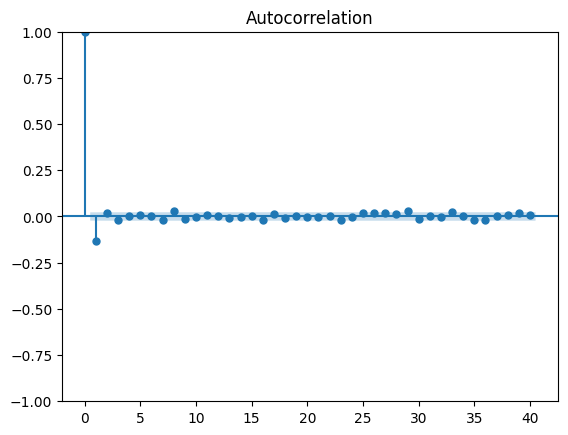

In [36]:

plot_acf(exchange_diff, lags=40, ax=plt.gca())
plt.show()

- Lag 0 = 1 (always)
- Lag 1 = small negative spike
- All other lags ≈ 0 and inside confidence band
No strong autocorrelation after lag 1 and ACF cuts off immediately

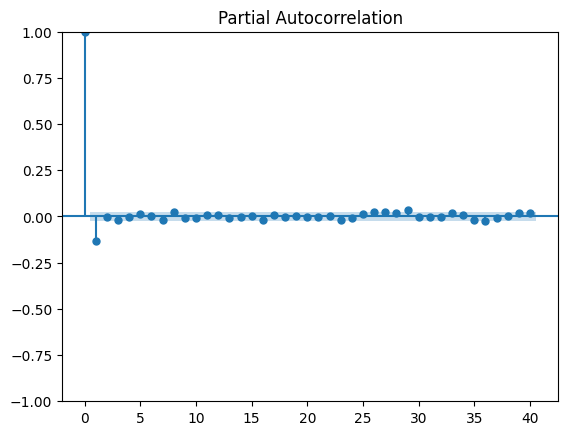

In [37]:
plot_pacf(exchange_diff, lags=40, ax=plt.gca())
plt.show()

- Lag 1 = small negative spike
- All other lags ≈ 0
PACF also cuts off at lag 1

ARIMA parameters
- d = 1 (already did differencing)
- p = 0 or 1
- q = 0 or 1

Based on these observations, the following ARIMA models were considered:
- ARIMA(0,1,1)
- ARIMA(1,1,0)
- ARIMA(1,1,1)
I use ARIMA(0,1,1) and ARIMA(1,1,0) for training

In [38]:
import warnings
warnings.filterwarnings('ignore')

In [59]:
## ## Model fitting for ARIMA(0,1,1)

In [50]:
## Model fitting
model = ARIMA(exchange['Ex_rate'],order=(0,1,1))
model_fit = model.fit()

In [40]:
model_fit.predict()

,predicted_mean
date,
01-01-1990 00:00,0.000000
02-01-1990 00:00,0.785500
03-01-1990 00:00,0.782278
04-01-1990 00:00,0.786119
05-01-1990 00:00,0.786016
...,...
06-10-2010 00:00,0.718826
07-10-2010 00:00,0.718538
08-10-2010 00:00,0.721405


In [47]:
forecast = model_fit.forecast(10)
forecast

,predicted_mean
7588,0.720862
7589,0.720862
7590,0.720862
7591,0.720862
7592,0.720862
7593,0.720862
7594,0.720862
7595,0.720862
7596,0.720862
7597,0.720862


In [52]:
residuals = model_fit.resid
residuals

,0
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,-0.003700
03-01-1990 00:00,0.004422
04-01-1990 00:00,-0.000119
05-01-1990 00:00,-0.001116
...,...
06-10-2010 00:00,-0.000332
07-10-2010 00:00,0.003301
08-10-2010 00:00,0.001792


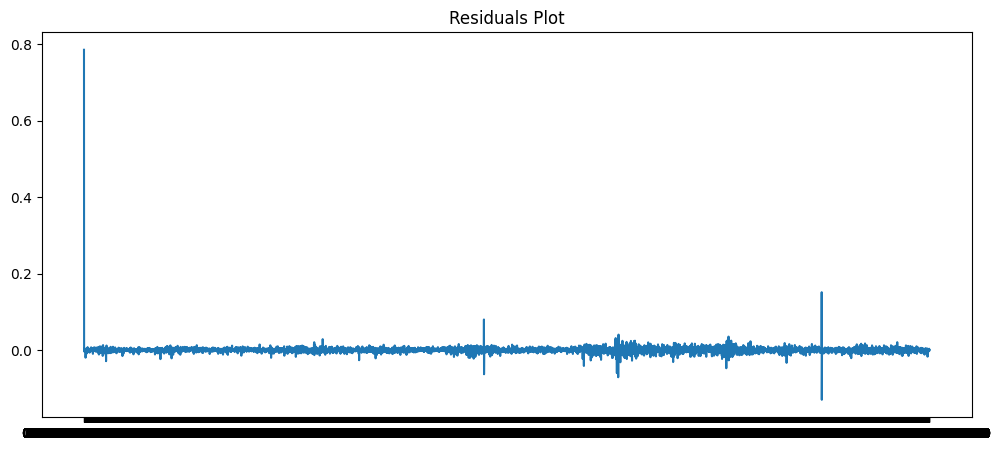

In [53]:
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title('Residuals Plot')
plt.show()

From the residual plot we can see that,
- Mostly values around 0
- Random small fluctuations
- No clear pattern
That means the model is good and adequate

In [45]:
exchange['Predicted'] = model_fit.predict()
exchange.head()

,Ex_rate,Predicted
date,,
01-01-1990 00:00,0.7855,0.000000
02-01-1990 00:00,0.7818,0.785500
03-01-1990 00:00,0.7867,0.782278
04-01-1990 00:00,0.7860,0.786119
05-01-1990 00:00,0.7849,0.786016


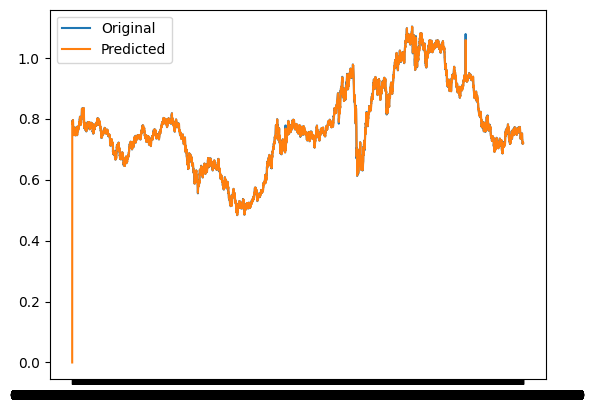

In [49]:
plt.plot(exchange['Ex_rate'],label='Original')
plt.plot(exchange['Predicted'],label='Predicted')
plt.legend()
plt.show()

In [85]:
## Model fitting for ARIMA(1,1,0)

In [73]:
model2 = ARIMA(exchange['Ex_rate'],order=(1,1,0))
model_fit2 = model2.fit()

In [74]:
model_fit2.predict()

,predicted_mean
date,
01-01-1990 00:00,0.000000
02-01-1990 00:00,0.785500
03-01-1990 00:00,0.782286
04-01-1990 00:00,0.786056
05-01-1990 00:00,0.786092
...,...
06-10-2010 00:00,0.718837
07-10-2010 00:00,0.718521
08-10-2010 00:00,0.721399


In [75]:
model_fit2.forecast(10)

,predicted_mean
7588,0.720825
7589,0.720825
7590,0.720825
7591,0.720825
7592,0.720825
7593,0.720825
7594,0.720825
7595,0.720825
7596,0.720825
7597,0.720825


In [76]:
model_fit2.resid

,0
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,-0.003700
03-01-1990 00:00,0.004414
04-01-1990 00:00,-0.000056
05-01-1990 00:00,-0.001192
...,...
06-10-2010 00:00,-0.000343
07-10-2010 00:00,0.003318
08-10-2010 00:00,0.001798


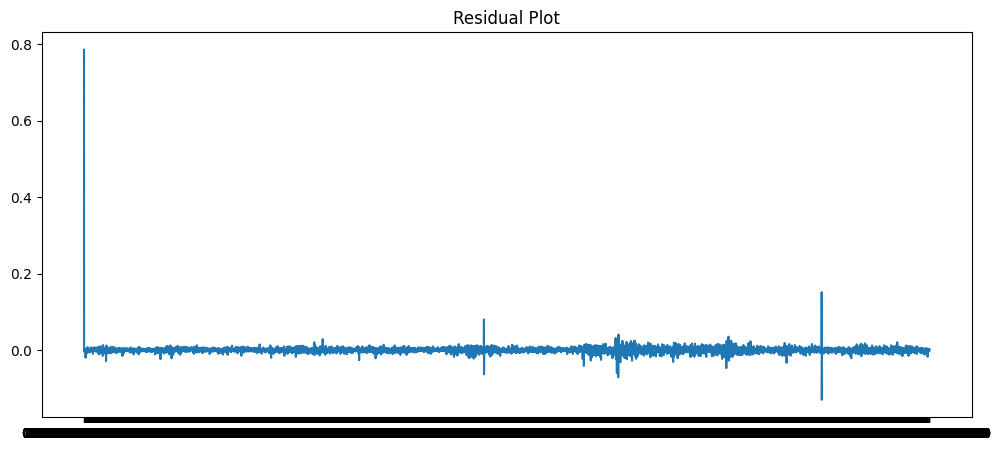

In [77]:
plt.figure(figsize=(12,5))
plt.plot(model_fit2.resid)
plt.title('Residual Plot')
plt.show()

- There is no pattern
- Random Fluctuations
- Most values around 0
The model is good and adequate

In [78]:
exchange['Predicted2'] = model_fit2.predict()
exchange.head()

,Ex_rate,Predicted,Predicted2
date,,,
01-01-1990 00:00,0.7855,0.000000,0.000000
02-01-1990 00:00,0.7818,0.785500,0.785500
03-01-1990 00:00,0.7867,0.782278,0.782286
04-01-1990 00:00,0.7860,0.786119,0.786056
05-01-1990 00:00,0.7849,0.786016,0.786092


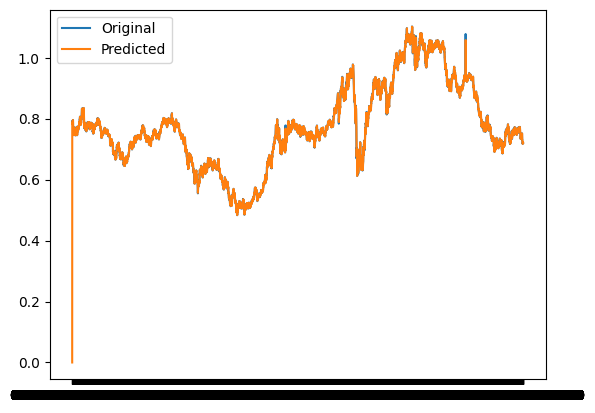

In [79]:
plt.plot(exchange['Ex_rate'],label='Original')
plt.plot(exchange['Predicted2'],label='Predicted')
plt.legend()
plt.show()

Part 3: Evaluation and Comparison

1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.


In [80]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error

In [81]:
mse1 = mean_absolute_error(exchange['Ex_rate'],exchange['Predicted'])
mse2 = mean_absolute_error(exchange['Ex_rate'],exchange['Predicted2'])

In [82]:
rmse1 = root_mean_squared_error(exchange['Ex_rate'],exchange['Predicted'])
rmse2 = root_mean_squared_error(exchange['Ex_rate'],exchange['Predicted2'])

In [83]:
mape1 = mean_absolute_percentage_error(exchange['Ex_rate'],exchange['Predicted'])
mape2 = mean_absolute_percentage_error(exchange['Ex_rate'],exchange['Predicted2'])

In [84]:
dict = {'Model':['ARIMA(0,1,1)','ARIMA(1,1,0)'],'MSE':[mse1,mse2],'RMSE':[rmse1,rmse2],'MAPE':[mape1,mape2]}
matrix = pd.DataFrame(dict)
matrix

,Model,MSE,RMSE,MAPE
0,"ARIMA(0,1,1)",0.003796,0.010829,0.004952
1,"ARIMA(1,1,1)",0.003796,0.010829,0.004951


1.

- Two models, ARIMA(0,1,1) and ARIMA(1,1,0), were evaluated using performance metrics.
- Both models produced identical RMSE values (0.010829), indicating similar prediction accuracy.
- The MAPE values were also nearly identical, with ARIMA(1,1,0) having a slightly lower value.
- The difference in performance between the two models is negligible.

2.
Performance
- Both models produced almost identical RMSE values, indicating similar prediction accuracy.
- The MAPE values were also nearly the same, with ARIMA(1,1,0) performing marginally better.
- The difference in error metrics is negligible, suggesting that both models capture the data behavior equally well.
- Both models have comparable forecasting performance

Advantages

ARIMA(0,1,1)
- Simpler model (fewer parameters)
- Faster to train and compute
- Lower risk of overfitting
- Works well for random walk-like data

ARIMA(1,1,0)
- More flexible (captures both AR and MA components)
- Can model slightly more complex relationships
- Slightly better MAPE (even if very small)

Limitations

ARIMA(0,1,1)
- May miss some patterns if data is complex
- Assumes no strong autoregressive behavior

ARIMA(1,1,0)
- More complex → risk of overfitting
- Higher computational cost
- Adds parameters without significant improvement

3.
- Both ARIMA(0,1,1) and ARIMA(1,1,0) models demonstrated strong forecasting performance with nearly identical error metrics.
- While ARIMA(1,1,0) showed a marginally lower MAPE, the difference was insignificant.
- Considering the principle of model parsimony, ARIMA(0,1,1) is preferred due to its simplicity and comparable accuracy.
- The results indicate that exchange rate data behaves like a random walk, where simpler models are often sufficient for accurate forecasting.